EDA - Synthetic Data 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
HERE = os.getcwd()
PARENT = os.path.dirname(HERE)

FIG_DIR = os.path.join(HERE, "..", "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
clean = pd.read_csv(os.path.join(PARENT,"data", "synthetic_clean.csv"), parse_dates=["date"])
conf = pd.read_csv(os.path.join(PARENT,"data", "synthetic_confounded.csv"), parse_dates=["date"])
spend_cols = [c for c in clean.columns if c.endswith("_spend")]

In [4]:
clean.head()

,week,date,revenue,tv_spend,search_spend,social_spend,display_spend,email_spend
0,0,2021-01-04,489.275590,44.899288,24.947920,20.786270,16.832811,6.066319
1,1,2021-01-11,498.078880,24.250293,14.108482,16.473337,19.647984,5.695629
2,2,2021-01-18,531.660454,35.869424,23.911752,22.787332,10.784192,4.376359
3,3,2021-01-25,498.296557,23.679510,19.046745,12.861278,6.189486,5.773422
4,4,2021-02-01,550.331317,36.521011,25.856235,18.028526,11.068548,4.880853


In [5]:
conf.head()

,week,date,revenue,tv_spend,search_spend,social_spend,display_spend,email_spend,demand
0,0,2021-01-04,401.596686,30.948515,12.989904,14.354017,7.877714,4.816509,-0.385773
1,1,2021-01-11,421.396035,32.270052,13.233479,24.838269,11.518321,8.533140,-0.403417
2,2,2021-01-18,512.805125,34.961400,21.428915,10.369072,13.687492,7.553851,-0.179975
3,3,2021-01-25,512.281447,28.666065,15.593591,21.005643,6.683969,5.906198,-0.398652
4,4,2021-02-01,580.702387,38.949083,34.146489,26.348927,12.795717,4.724102,0.289707


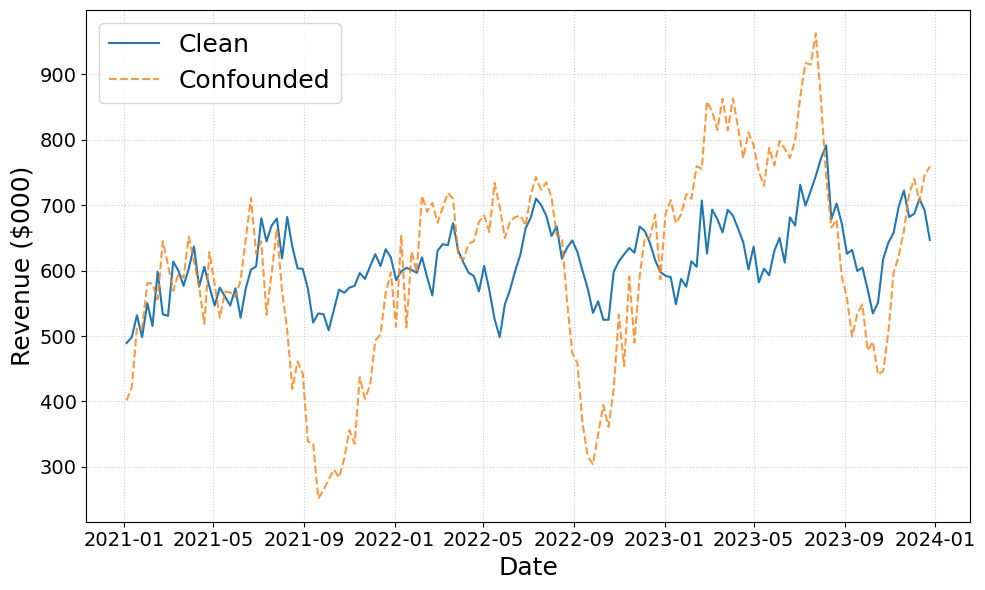

In [16]:
# Create a single plot instead of a grid
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both datasets on the same axes
ax.plot(
    clean.date, clean.revenue, lw=1.5, label="Clean", color="tab:blue"
)
ax.plot(
    conf.date,
    conf.revenue,
    lw=1.5,
    alpha=0.8,
    label="Confounded",
    color="tab:orange",
    linestyle="--",
)

# Style and label the plot
# ax.set_title("Weekly Revenue ($000): Clean vs. Confounded", fontsize=14, pad=15)
ax.set_xlabel("Date", fontsize=18)
ax.set_ylabel("Revenue ($000)", fontsize=18)

# Increase the font size of the actual numbers on the x and y axes
ax.tick_params(axis="both", which="major", labelsize=14)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(fontsize=18, loc="upper left")

plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(FIG_DIR, "revenue_clean_vs_confounded.png"), dpi=300)

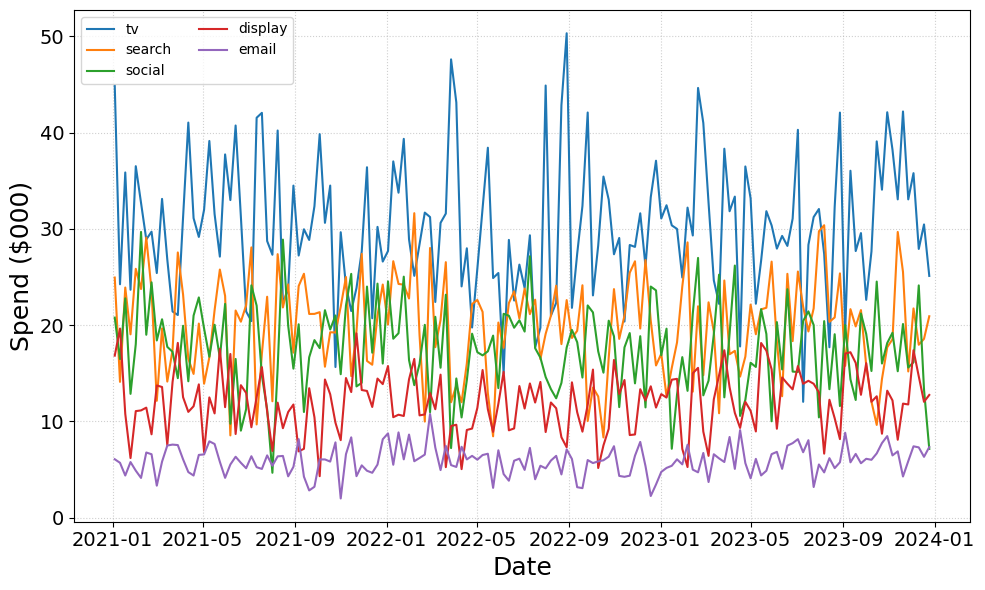

In [21]:
# Create a single plot instead of a grid
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each spend channel series on the same axes
for c in spend_cols:
    ax.plot(clean.date, clean[c], lw=1.5, label=c.replace("_spend", ""))

# Style and label the plot
# ax.set_title("Channel Spend, Clean ($000/week)", fontsize=14, pad=15)
ax.set_xlabel("Date", fontsize=18)
ax.set_ylabel("Spend ($000)", fontsize=18)

# Increase the font size of the actual numbers on the x and y axes
ax.tick_params(axis="both", which="major", labelsize=14)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(fontsize=10, ncol=2, loc="upper left")

plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(FIG_DIR, "channel_spend_clean.png"), dpi=300)

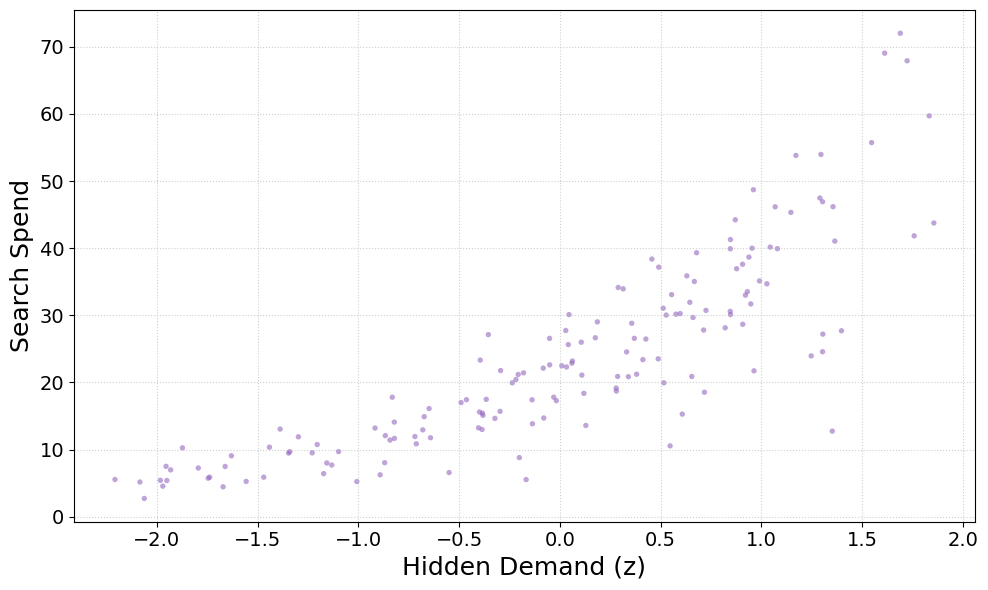

In [19]:
# Create a single plot instead of a grid
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate the correlation coefficient
r = np.corrcoef(conf["demand"], conf["search_spend"])[0, 1]

# Plot the scatter data
ax.scatter(
    conf["demand"],
    conf["search_spend"],
    s=15,
    alpha=0.6,
    color="tab:purple",
    edgecolors="none",
)

# Style and label the plot
# ax.set_title(
#     f"Confounding: Spend Rises with Demand (r = {r:+.2f})", fontsize=14, pad=15
# )
ax.set_xlabel("Hidden Demand (z)", fontsize=18)
ax.set_ylabel("Search Spend", fontsize=18)
ax.grid(True, linestyle=":", alpha=0.6)

ax.tick_params(axis="both", which="major", labelsize=14)

plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(FIG_DIR, "confounding_demand_search.png"), dpi=300)

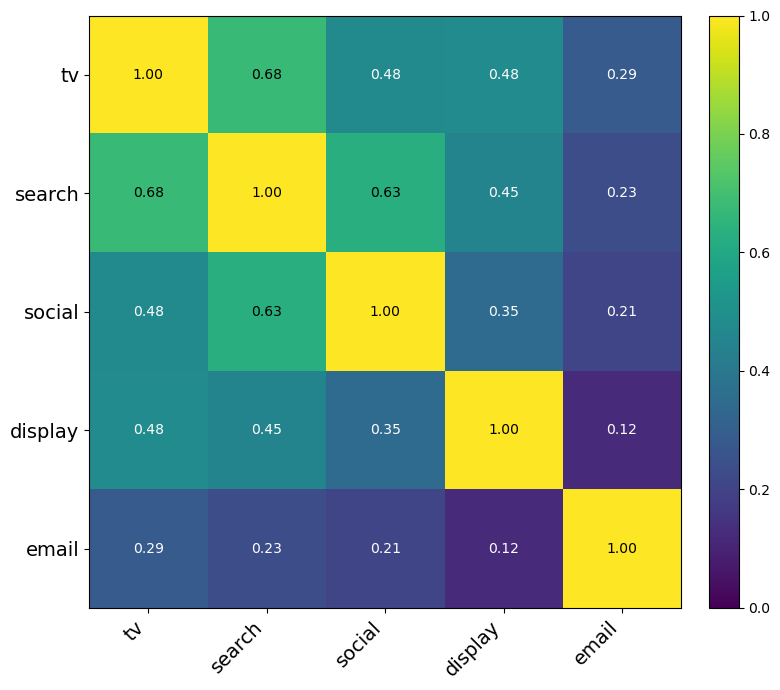

In [18]:
# Create a single plot instead of a grid
fig, ax = plt.subplots(figsize=(8, 7))

# Calculate correlation matrix
corr = conf[spend_cols].corr()

# Display the heatmap
im = ax.imshow(corr, vmin=0, vmax=1, cmap="viridis")

# Set up axis ticks and labels
ax.set_xticks(range(len(spend_cols)))
ax.set_yticks(range(len(spend_cols)))
labels = [c.replace("_spend", "") for c in spend_cols]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

# Title
# ax.set_title("Channel Spend Correlation (Confounded)", fontsize=14, pad=15)

# Annotate values inside the heatmap
for i in range(len(spend_cols)):
    for j in range(len(spend_cols)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if corr.iloc[i, j] < 0.6 else "black",
            fontsize=10,
        )

# Add colorbar
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Increase the font size of the actual numbers on the x and y axes
ax.tick_params(axis="both", which="major", labelsize=14)

plt.tight_layout()
# plt.show()
plt.savefig(os.path.join(FIG_DIR, "channel_spend_correlation.png"), dpi=300)